*Note: run train_test_val_split.ipynb before running this notebook*

In [1]:
import pandas as pd
import numpy as np
import igraph as ig
from collections import defaultdict

## Data Preparation
- According to the PaySim data documentation, the type of fraud simulated involves the transfer of stolen funds. Fraudulent users first TRANSFER money from a victim account to a mule account, which then CASH_OUTS the funds
- The dataset is filtered to include only these relevant transaction types.
- We prepare the DataFrame for graph construction by creating sender (u) and receiver (v) identifiers and encoding transaction types as binary flags (is_transfer, is_cashout).
- The logarithm of the transaction amount is added as an additional feature to account for nonlinear effects in transaction size distributions.

In [2]:
TX_KEEP = {"TRANSFER", "CASH_OUT"}

def prep_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.loc[df["type"].isin(TX_KEEP)].copy()
    df = df.sort_values("step").reset_index(drop=True)
    df["u"] = df["nameOrig"]
    df["v"] = df["nameDest"]
    df["pair_key"] = df["u"] + "→" + df["v"]
    df["is_transfer"] = (df["type"] == "TRANSFER").astype(int)
    df["is_cashout"]  = (df["type"] == "CASH_OUT").astype(int)
    df["log_amount"]  = np.log1p(df["amount"])
    return df

## Graph helper functions
In order to assign centrality scores for each time window, we construct helper functions to
1. Aggregate multiple transactions (grouped by the u-v pair) into one edge, with the number of transactions and the total transacted value as edge features
2. Compute node centralities for BOTH u and v, for now we only include degree centrality, any additional measures can be added in (betweenness left out due to computational cost)
3. Split data into "blocks" of time, in which the network graph is built solely with data prior to it. This is to prevent data leakage, ensuring that information from future transactions does not influence feature computation for past events. block_size defines the number of hours within one block of time, window_size defines the number of hours prior to the block of time which is considered within the network.


In [3]:
def build_edgelist(edgelist: pd.DataFrame) -> pd.DataFrame:
    if edgelist.empty:
        return pd.DataFrame(columns=["u","v","w_amount","w_count"])
    agg = (edgelist
           .groupby(["u","v"])
           .agg(w_amount=("amount","sum"),
                w_count =("amount","size"))
           .reset_index())
    return agg

In [4]:
def compute_centralities(agg: pd.DataFrame) -> dict:
    if agg.empty:
        return {
            "pr": defaultdict(float),
            "outdeg_amt": defaultdict(float),
            "indeg_amt": defaultdict(float),
            "outdeg_cnt": defaultdict(float),
            "indeg_cnt": defaultdict(float),
        }

    # --- build igraph ---
    nodes = pd.Index(pd.concat([agg["u"], agg["v"]]).unique())
    node_to_idx = {n: i for i, n in enumerate(nodes)}

    g = ig.Graph(directed=True)
    g.add_vertices(len(nodes))
    g.vs["name"] = list(nodes)
    edges_idx = list(zip(agg["u"].map(node_to_idx),
                         agg["v"].map(node_to_idx)))
    g.add_edges(edges_idx)

    g.es["w_amount"] = agg["w_amount"].astype(float).tolist()
    g.es["w_count"]  = agg["w_count"].astype(float).tolist()

    # --- centralities ---
    pr = g.pagerank(weights="w_amount")
    outdeg_amt = g.strength(mode="OUT", weights="w_amount")
    indeg_amt  = g.strength(mode="IN",  weights="w_amount")
    outdeg_cnt = g.strength(mode="OUT", weights="w_count")
    indeg_cnt  = g.strength(mode="IN",  weights="w_count")

    names = g.vs["name"]
    return {
        "pr": dict(zip(names, pr)),
        "outdeg_amt": dict(zip(names, outdeg_amt)),
        "indeg_amt":  dict(zip(names, indeg_amt)),
        "outdeg_cnt": dict(zip(names, outdeg_cnt)),
        "indeg_cnt":  dict(zip(names, indeg_cnt)),
    }

In [5]:
def rolling_features(df: pd.DataFrame,
                                   block_size: int = 10,
                                   window_size: int = 50) -> pd.DataFrame:
    df = df.copy()
    df["block"] = (df["step"] // block_size).astype(int)

    # placeholder columns
    for col in [
        "sender_pr","receiver_pr",
        "sender_outdeg_amt","sender_indeg_amt",
        "receiver_outdeg_amt","receiver_indeg_amt",
        "sender_outdeg_cnt","sender_indeg_cnt",
        "receiver_outdeg_cnt","receiver_indeg_cnt",
        "pagerank_diff","outdeg_amt_diff","indeg_amt_diff",
        "outdeg_cnt_diff","indeg_cnt_diff"
    ]:
        df[col] = 0.0

    for b in sorted(df["block"].unique()):
        block_mask = df["block"] == b
        block_min_step = int(df.loc[block_mask, "step"].min())
        hist_mask = (df["step"] < block_min_step) & (df["step"] >= block_min_step - window_size)
        hist_edges = df.loc[hist_mask, ["u","v","amount","step"]]
        agg = build_edgelist(hist_edges)
        cent = compute_centralities(agg)

        idx = df.index[block_mask]
        df.loc[idx, "sender_pr"] = df.loc[idx, "u"].map(cent["pr"]).fillna(0.0)
        df.loc[idx, "receiver_pr"] = df.loc[idx, "v"].map(cent["pr"]).fillna(0.0)

        df.loc[idx, "sender_outdeg_amt"] = df.loc[idx, "u"].map(cent["outdeg_amt"]).fillna(0.0)
        df.loc[idx, "sender_indeg_amt"]  = df.loc[idx, "u"].map(cent["indeg_amt"]).fillna(0.0)
        df.loc[idx, "receiver_outdeg_amt"] = df.loc[idx, "v"].map(cent["outdeg_amt"]).fillna(0.0)
        df.loc[idx, "receiver_indeg_amt"]  = df.loc[idx, "v"].map(cent["indeg_amt"]).fillna(0.0)

        df.loc[idx, "sender_outdeg_cnt"] = df.loc[idx, "u"].map(cent["outdeg_cnt"]).fillna(0.0)
        df.loc[idx, "sender_indeg_cnt"]  = df.loc[idx, "u"].map(cent["indeg_cnt"]).fillna(0.0)
        df.loc[idx, "receiver_outdeg_cnt"] = df.loc[idx, "v"].map(cent["outdeg_cnt"]).fillna(0.0)
        df.loc[idx, "receiver_indeg_cnt"]  = df.loc[idx, "v"].map(cent["indeg_cnt"]).fillna(0.0)

        df.loc[idx, "pagerank_diff"]  = df.loc[idx, "sender_pr"] - df.loc[idx, "receiver_pr"]
        df.loc[idx, "outdeg_amt_diff"] = df.loc[idx, "sender_outdeg_amt"] - df.loc[idx, "receiver_outdeg_amt"]
        df.loc[idx, "indeg_amt_diff"]  = df.loc[idx, "sender_indeg_amt"]  - df.loc[idx, "receiver_indeg_amt"]
        df.loc[idx, "outdeg_cnt_diff"] = df.loc[idx, "sender_outdeg_cnt"] - df.loc[idx, "receiver_outdeg_cnt"]
        df.loc[idx, "indeg_cnt_diff"]  = df.loc[idx, "sender_indeg_cnt"]  - df.loc[idx, "receiver_indeg_cnt"]

    return df

## Main function


In [6]:
def build_feature_table(df_raw: pd.DataFrame,
                        block_size=10,
                        window_size=50) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    df = prep_df(df_raw)
    df = rolling_features(df, block_size=block_size, window_size=window_size)

    feature_cols = [
        "amount","log_amount","is_transfer","is_cashout",
        "sender_pr","receiver_pr",
        "sender_outdeg_amt","sender_indeg_amt","receiver_outdeg_amt","receiver_indeg_amt",
        "sender_outdeg_cnt","sender_indeg_cnt","receiver_outdeg_cnt","receiver_indeg_cnt",
        "pagerank_diff","outdeg_amt_diff","indeg_amt_diff","outdeg_cnt_diff","indeg_cnt_diff",
    ]
    X = df[feature_cols].fillna(0).copy()
    y = df["isFraud"].astype(int)
    meta = df[["step","type","u","v","pair_key"]].copy()
    return X, y, meta

## Preparation of train/val//test data

Full dataset consists 31 days of data, with about 3 days of data in val and test. We arbitrarily set block_size to 12 and window_size to 48.



In [9]:
df_train = pd.read_csv('data/splits/train.csv')
df_val = pd.read_csv('data/splits/val.csv')
df_test = pd.read_csv('data/splits/test.csv')

Xtrain, ytrain, metatrain = build_feature_table(df_train, block_size=6, window_size=48)
Xval, yval, metaval = build_feature_table(df_val, block_size=6, window_size=48)
Xtest, ytest, metatest = build_feature_table(df_test, block_size=6, window_size=48)

## Preliminary classification

Initial model run with default settings — no hyperparameter tuning, or threshold optimisation applied.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

clf = RandomForestClassifier(
    n_estimators=1000, max_depth=None, min_samples_leaf=2,
    n_jobs=-1, random_state=42, class_weight="balanced"
)
clf.fit(Xtrain, ytrain)


RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       n_estimators=1000, n_jobs=-1, random_state=42)

ROC-AUC: 0.8148784223270392
PR-AUC : 0.21259094512582963


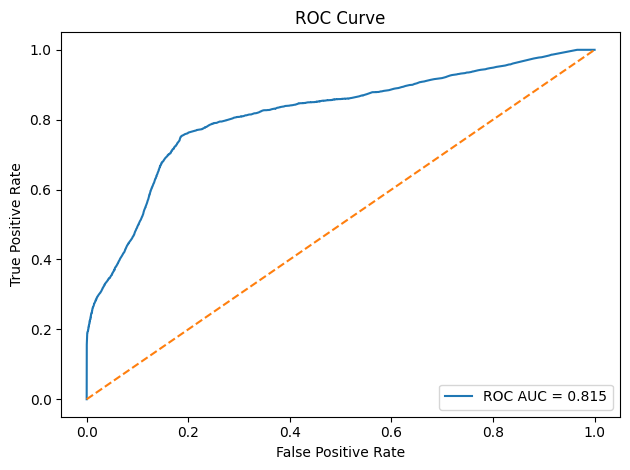

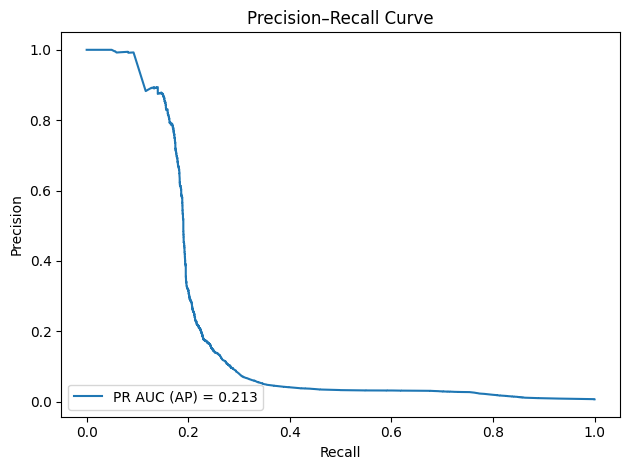

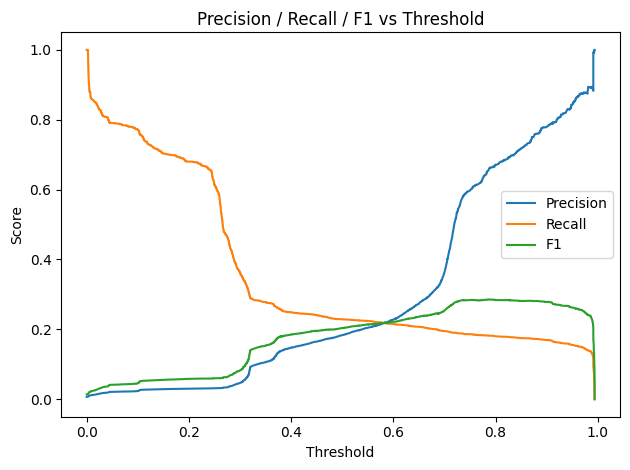

In [11]:
proba = clf.predict_proba(Xtest)[:,1]
print("ROC-AUC:", roc_auc_score(ytest, proba))
print("PR-AUC :", average_precision_score(ytest, proba))

y_true = ytest.astype(int)
y_score = proba

fpr, tpr, thr_roc = roc_curve(y_true, y_score)
roc_auc = roc_auc_score(y_true, y_score)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

prec, rec, thr_pr = precision_recall_curve(y_true, y_score)
ap = average_precision_score(y_true, y_score)

plt.figure()
plt.plot(rec, prec, label=f"PR AUC (AP) = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

thr = np.r_[0.0, thr_pr]  # prepend 0 to align lengths
f1 = 2 * (prec * rec) / np.clip(prec + rec, 1e-12, None)

plt.figure()
plt.plot(thr, prec, label="Precision")
plt.plot(thr, rec,  label="Recall")
plt.plot(thr, f1,   label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.legend()
plt.tight_layout()
plt.show()